# Temperature dependent band gap
**by <span style="color:darkgreen">Sebastian Tillack</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to use **`exciting`** to compute the demperature dependent band gap of Diamond from electron-phonon interaction.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**

[0. Before Starting](#0)  
[1. Theoretical Background](#1)  
[2. Electronic Structure](#2)   
[3. Lattice Vibrations](#3)   
[4. Electron-Phonon Interaction](#4)     
[5. Documentation, Technical Notes and Practical Tips](#5)     
</div>

<a id="0"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Before starting any tutorial, it is a good practice to create a subdirectory for each tutorial you are going to work on. For this tutorial the subdirectory could be called, *e.g.*, **run_temperature_dependent_band_gap**.  

**Note:** Electron-phonon interaction is an advanced feature of **`exciting`** and we recommend to make yourself familiar with other tutorials fist, especially the tutorials on **phonons** and **Wannier functions**.

We import a little bit of Python needed for this tutorial...

In [ ]:
from pathlib import Path
from excitingjupyter.utilities import get_input_xml_from_notebook
from excitingtools.input import ExcitingInputXML

tutorial_dir = Path('run_temperature_dependent_band_gap')

And create the working directory for this tutorial.

In [ ]:
%%bash
mkdir -p run_temperature_dependent_band_gap

<a id="1"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

Within this tutorial, we are going to compute the renormalization of the electronic energies in Diamond due to the interaction between electrons and lattice vibrations at both **0 Kelvin and finite temperatures**.
From this, we will determine the shift of the band-edges and hence the change in electronic band gap as a function of temperature. We will further compute the renormalized band structure at room temperature including the line width of the quasi particles.  

We will do this by means of **many-body perturbation theory** (MBPT). Therefore, we compute the **electron self-energy** due to electron-phonon interaction as an additional contribution to the Hamiltonian which will lead to renormalized quasi-particles as a result. The two main contributions to the electron self-energy are the so-called *Fan-Migdal* self-energy and the *Debye-Waller* self-energy.

$$
\Sigma^{\rm eph}_{n{\bf k}}(\omega;T) = \Sigma_{n{\bf k}}^{\rm FM}(\omega;T) + \Sigma_{n{\bf k}}^{\rm DW}(T)
$$

The ***Fan-Migdal*** self-energy is complex and dynamic, *i.e.*, it depends on the frequency $\omega$:

$$
\Sigma_{n{\bf k}}^{\rm FM}(\omega;T) = \sum_\nu \int\limits_{\rm BZ} \frac{{\rm d}{\bf q}}{V_{\rm BZ}} \sum_m |g_{mn,\nu}({\bf k},{\bf q})|^2 \left[ \frac{1-f_{m{\bf k}+{\bf q}}(T)+n_{\nu{\bf q}}(T)}{\omega - \epsilon^0_{m{\bf k}+{\bf q}} - \omega_{\nu{\bf q}} + {\rm i}\eta} + \frac{f_{m{\bf k}+{\bf q}}(T)+n_{\nu{\bf q}}(T)}{\omega - \epsilon^0_{m{\bf k}+{\bf q}} + \omega_{\nu{\bf q}} + {\rm i}\eta} \right] \;. \tag{1}
$$

The ***Debye-Waller*** self-energy on the other hand is real and static:

$$
\Sigma^{\rm DW}_{n{\bf k}}(T) = \sum\limits_{\nu} \int \frac{{\rm d}{\bf q}}{V_{\rm BZ}} g^{\rm DW}_{n,\nu}({\bf k},{\bf q}) \Big(  n_{\nu{\bf q}}(T) + \frac{1}{2} \Big) \;. \tag{2}
$$

In the equations above, ${\bf k}$ is the momentum of the electrons for which we want to compute the self-energy and $\epsilon^0_{n{\bf k}}$ the corresponding bare electron energies.  
${\bf q}$ is the phonon wavevector and $\omega_{\nu{\bf q}}$ the corresponding phonon mode frequencies.  
Temperature enters the expression via the Fermionic and Bosonic equilibrium distributions $f_{n{\bf k}}(T)=f(\epsilon^0_{n{\bf k}};T)$ and $n_{\nu{\bf q}}(T)=n(\omega_{\nu{\bf q}};T)$, respectively.  
$\eta$ is a positive infinitesimal smearing parameter.  

The key ingredient encoding the interaction between electron and lattice vibrations are the **electron-phonon matrix elements**

$$
g_{mn,\nu}({\bf k},{\bf q}) = \sum\limits_{\kappa,\alpha} \frac{e_{\kappa\alpha,\nu}({\bf q})}{\sqrt{2\, M_\kappa\, \omega_{\nu{\bf q}}}} \langle \psi_{m{\bf k}+{\bf q}} | v_{\rm KS}^{(\kappa\alpha{\bf q})} | \psi_{n{\bf k}} \rangle \;,
$$

where the sum runs over all atoms $\kappa$ and Cartesian directions $\alpha$, $M_{\kappa}$ is the mass of the nucleus of atom $\kappa$ and $e_{\kappa\alpha,\nu}({\bf q})$ are the eigenvectors of the dynamical matrices.  
Most importantly, $v_{\rm KS}^{(\kappa\alpha{\bf q})}$ is the linear *response of the Kohn-Sham potential* to a wave-like displacement of all replica of atom $\kappa$ with a modulating wavevector ${\bf q}$.  

The matrix-elements $g^{\rm DW}_{n,\nu}({\bf k},{\bf q})$ in principle would require the second-order response of the Kohn-Sham potential. Within the so-called *rigid-ion approximation* (RIA), they can however be expressed in terms of the first-order response of the potential.

Once we have obtained the electron self-energy, we can solve the **quasi-particle equation** 

$$
\epsilon_{n{\bf k}}^{\rm QP}(T) = \epsilon_{n{\bf k}}^0 + \Sigma^{\rm eph}_{n{\bf k}}(\epsilon_{n{\bf k}}^{\rm QP},T)
$$

for the renormalized quasi-particle energies $\epsilon_{n{\bf k}}^{\rm QP}$.

<a id="2"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Electronic Structure</span>

As the first step, we have to compute electronic structure without electron-phonon interaction. As a good practice, we recommend to separate calculations and therefore create a subdirectory called **electrons** for the electronic part.

In [ ]:
%%bash
mkdir -p run_temperature_dependent_band_gap/electrons

As an additional prerequisite for the calculation of the electron self-energy, we also have to compute **maximally localized Wannier functions** (MLWFs). To understand why, we recall the self-energy expression Eq. (1). The terms in square brackets are resonant when the frequency $\omega$ matches the electronic energies $\epsilon_{m{\bf k}+{\bf q}}$ plus or minus a phonon frequency $\pm \omega_{\nu{\bf q}}$. Typical electron energies are in the range of 1s to 10s of eV, while phonon frequencies are typically in the range of a few 10s to 100s of meV, , *i.e.*, at least one order of magnitude smaller. Therefore, a **very fine sampling of the Brillouin zone** is required to capture all the small energy differences. In most cases, however, it is prohibitive to directly compute phonons on such dense ${\bf q}$-grids. This problem is solved by computing the electrons and phonons on relatively coarse ${\bf k}$ and ${\bf q}$-grids and then employ some sort of interpolation to obtain all quantities on fine integration grids. A very accurate interpolation scheme that is commonly employed is **Wannier-Fourier interpolation**. Therefore, we also need to compute MLWFs.

The input file for the electronic structure looks like this:

<span class="ELECTRON_INPUT"></span>
```xml
<input>

   <title>Diamond - electronic structure</title>

   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="6.7274">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>

      <species speciesfile="C.xml">
         <atom coord="0.00 0.00 0.00"/>
         <atom coord="0.25 0.25 0.25"/>
      </species>

   </structure>

   <groundstate
      do="fromscratch"
      ngridk="4 4 4"
      outputlevel="normal"
      nempty="50"
      >
      <libxc exchange="XC_GGA_X_PBE_SOL" correlation="XC_GGA_C_PBE_SOL"/>
   </groundstate>
   
   <properties>
      <wannier do="fromscratch">
        <group
           fst="1"
           lst="4"
           />
        <group
           innerwindow="0.0 2.0"
           outerwindow="0.0 3.0"
           />
      </wannier>
   </properties>

</input>

```

You can either copy the input to the file **input.xml** or use the following script to extract it from this notebook.

In [ ]:
electron_dir = tutorial_dir / 'electrons'
input_str = get_input_xml_from_notebook('temperature_dependent_band_gap', 'ELECTRON_INPUT')

# Write out the input as an XML file:
with open(electron_dir / 'input.xml', 'w') as fid:
    fid.write(input_str)

In principal, we would now run **`exciting`** and compute the electronic structure. 

**Note**: For the sake of reproducability, we provide the important results of this step. We have observed that different compilers can arrive at different results for the MLWFs. In this underconverged calculation with very coarse ${\bf k}$ and ${\bf q}$-grids for the electrons and phonons, respectively, differences in the Wannier interpolation can lead do differences in the quantities computed from electron-phonon interaction beyond numerical differences. In practical calculations with more converged settings, these differences would be much smaller.

In [ ]:
%%bash
cd run_temperature_dependent_band_gap/electrons

# copy reference results
cp ../../temperature_dependent_band_gap_ref/* .

<a id="3"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Lattice Vibrations</span>

The next prerequisite is the calculation of the phonons. Again, we do this in a separate directory called **phonons**.

In [ ]:
%%bash
mkdir -p run_temperature_dependent_band_gap/phonons

The corresponding input looks like that and you should already be familiar with all the elements in it at this point.

<span class="PHONON_INPUT"></span>
```xml
<input>

   <title>Diamond - lattice vibrations</title>

   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="6.7274">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>

      <species speciesfile="C.xml">
         <atom coord="0.00 0.00 0.00"/>
         <atom coord="0.25 0.25 0.25"/>
      </species>

   </structure>

   <groundstate
      do="skip"
      ngridk="4 4 4"
      outputlevel="normal"
      nempty="50"
      >
      <libxc exchange="XC_GGA_X_PBE_SOL" correlation="XC_GGA_C_PBE_SOL"/>
   </groundstate>
   
   <phonons
      do="fromscratch"
      ngridq="2 2 2"
      polar="false"
      >
   </phonons>

</input>

```

Let's extract the input and write it to file.

In [ ]:
phonon_dir = tutorial_dir / 'phonons'
input_str = get_input_xml_from_notebook('temperature_dependent_band_gap', 'PHONON_INPUT')

# Write out the input as an XML file:
with open(phonon_dir / 'input.xml', 'w') as fid:
    fid.write(input_str)

Before we can execute the phonon calculation, we need to provide all necessary input from the electronic structure. In this case, only the file `STATE.OUT` is required which we provide via a soft link.  

**Note**: The calculation of the phonons might take a few minutes.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/phonons

# provide necessary files
ln -s ../electrons/STATE.OUT .

# run exciting
python3 -m excitingscripts.setup.excitingroot
time python3 -m excitingscripts.execute.single

In contrast to a standard phonon calculation, we have to apply an additional step to write the files containing the response of the Kohn-Sham potential $v_{\rm KS}^{(\kappa\alpha{\bf q})}$. This has already been computed in the step before, but we need to transform the results obtained in the basis of irreducible representation into the canonical basis of $(\kappa,\alpha)$ displacements. This can be done by setting the attribute <code><span style="color:mediumblue">do</span></code> to `"fromfile"` and only running the part `"phonons_write_dpot"`. To do this, modify the <code><span style="color:green">phonons</span></code> element in the input file as follows or use the Python code below to do this.

```xml
<phonons
  do="fromfile"
  ngridq="2 2 2"
  polar="false"
  >
  <parts>
    <dopart id="phonons_write_dpot"/>
  </parts>
</phonons>
```

In [ ]:
# Read input file into ExctingInput object:
exciting_input = ExcitingInputXML.from_xml(phonon_dir / 'input.xml')

exciting_input.phonons.do = 'fromfile'
exciting_input.phonons.parts = {'dopart': [{'id': 'phonons_write_dpot'}]}

exciting_input.write(phonon_dir / 'input.xml')

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/phonons

# run exciting
python3 -m excitingscripts.setup.excitingroot
time python3 -m excitingscripts.execute.single

<a id="4"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Electron-Phonon Interaction</span>

We are now prepared to start the interesting part of this tutorial. Again, we create a new subdirectory to run our electron-phonon calculations in and simply call it **eph**.

In [ ]:
%%bash
mkdir -p run_temperature_dependent_band_gap/eph

<a id="4.1"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">4.1. Checking electrons and phonons</span>

As a first step, want to check, if the results from the two previous steps look reasonable. Therefore, we will plot the electronic band structure using Wannier interpolation and the phonon band structure using Fourier interpolation. This will show us, if the interpolation works as expected and that the correct electron and phonon energies will enter the calculation of the self-energy later. The input file that does this looks like that:

<span class="EPH_INPUT"></span>
```xml
<input>

   <title>Diamond - electron-phonon interaction</title>

   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="6.7274">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>

      <species speciesfile="C.xml">
         <atom coord="0.00 0.00 0.00"/>
         <atom coord="0.25 0.25 0.25"/>
      </species>

   </structure>

   <groundstate
      do="skip"
      ngridk="4 4 4"
      outputlevel="normal"
      nempty="50"
      >
      <libxc exchange="XC_GGA_X_PBE_SOL" correlation="XC_GGA_C_PBE_SOL"/>
   </groundstate>
   
   <properties>
      <wannier do="skip">
        <group
           fst="1"
           lst="4"
           />
        <group
           innerwindow="0.0 2.0"
           outerwindow="0.0 3.0"
           />
      </wannier>
   </properties>
   
   <phonons
      do="skip"
      ngridq="2 2 2"
      polar="false"
      >
   </phonons>
   
   <eph wfrange="1 18">
      <target>      
         <plot1d>
            <path steps="100">
               <point coord="1.0     0.0     0.0" label="Gamma"/>
               <point coord="0.625   0.375   0.0" label="K"/>
               <point coord="0.5     0.5     0.0" label="X"/>
               <point coord="0.0     0.0     0.0" label="Gamma"/>
               <point coord="0.5     0.0     0.0" label="L"/>
            </path>
         </plot1d>
      </target>      
      <el_interpolation format="json"/>
      <ph_interpolation format="json"/>
   </eph>

</input>

```

Note that all the previous elements <code><span style="color:green">groundstate</span></code>, <code><span style="color:green">wannier</span></code> and <code><span style="color:green">phonons</span></code> still need to be present, but we can set the attribute <code><span style="color:mediumblue">do</span></code> to `"skip"` in all of them.

The new input element <code><span style="color:green">eph</span></code> in this example takes the following form:

* The element <code><span style="color:green">target</span></code> provides a set of target wavevectors. Depending on the context, this can either refer to electron wavevectors ${\bf k}$ or phonon wavevectors ${\bf q}$.  
  The target can describe either a regular grid of points (which we will use later) or a path through the Brillouin zone as in this example. The path is provided by the <code><span style="color:green">plot1d</span></code> element which you already know, *e.g.* from band structure calculations.
* The elements <code><span style="color:green">el_interpolation</span></code> and <code><span style="color:green">ph_interpolation</span></code> triggers the interpolation of the electron and phonon energies on the specified set of target wavevectors. For both, we explicitly specify the output <code><span style="color:mediumblue">format</span></code> `"json"` to write the results to a JSON file for easy parsing.
* The attribute <code><span style="color:mediumblue">wfrange</span></code> specifies the range of Wannier bands to include in the electron-phonon calculation. As a reminder: Only electronic states whose energy falls inside the <code><span style="color:mediumblue">innerwindow</span></code> specified in the <code><span style="color:green">group</span></code>s of a Wannier calculation are described accurately. Therefore, we only want to include those bands in our calculation. In this example, the four valence bands described by the first group form an isolated set and are described exactly. In the second group describing the lowest conduction bands, the bands are entangled and only some of them are described accurately. In this example the lowest 14 bands. Therefore, over all groups Wannier bands 1 to 18 (4+14) are considered as accurate. To find out how many bands to include, you can consult the file `WANNIER_INFO.OUT`. Therein, you will find the following information for the second group telling you that the smallest number of bands (taken over all ${\bf k}$-points) that fall inside the innner window is 14.
  ```
  --------------------------------------------------------------------------------
  - Group:  2                                                                    -
  --------------------------------------------------------------------------------
  
  lowest band:                               5
  highest band:                             30
  #bands involved:                          26
  #Wannier functions:                       20
  #projection functions (nc):              100
  method:                              disFull
  outer window:                0.0000   3.0000
  inner window:                0.0000   2.0000
  min/max bands inner window:          14/  18
  min/max bands outer window:          22/  26
  ```
  Alternatively, you can ignore the attribute <code><span style="color:mediumblue">wfrange</span></code> at this verification step and only enable it later for the actual calculation. **`exciting`** will analyze the band structure for you and tells you which bands are described exactly.

So let's write the input to the file `input_check.xml`...

In [ ]:
eph_dir = tutorial_dir / 'eph'
input_str = get_input_xml_from_notebook('temperature_dependent_band_gap', 'EPH_INPUT')

# Write out the input as an XML file:
with open(eph_dir / 'input_check.xml', 'w') as fid:
    fid.write(input_str)

...and run the code. Before we can do this, we need to provide all the necessary output files from the previous steps which serve as the input for the electron-phonon calculation. These are the following:

* `STATE.OUT`, `EFERMI.OUT`, `EVECFV.OUT`, `EVECSV.OUT`, `EVALFV.OUT`, `EVALSV.OUT`, `WANNIER_TRANSFORM.OUT` from the **electrons** subdirectory
* all `DYN_Q####_####_####_S##_A###.OUT` (dynamical matrices) and `DVEFF_Q####_####_####_S##_A###.OUT` (potential response) files (and `EPSINF.OUT` and `ZSTAR.OUT` for polar materials) from the **phonons** subdirectory

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

# provide necessary files
ln -s ../electrons/{STATE.OUT,EFERMI.OUT,EVECFV.OUT,EVECSV.OUT,EVALFV.OUT,EVALSV.OUT,WANNIER_TRANSFORM.OUT} .
ln -s ../phonons/{DYN_*,DVEFF_*} .

# run exciting
python3 -m excitingscripts.setup.excitingroot -i input_check.xml -o input_check.xml
time python3 -m excitingscripts.execute.single -f input_check.xml

This step (among a few other files) generates the files `eph_el_disp.json` and `eph_ph_disp.json` containing the electron and phonon dispersion along the specified path.  
Note also the printed info about the analyzed (Wannier) band structure.

We can visualize the results using the script `eph_dispersion` and providing the respective JSON files via the argument `-disp`:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_dispersion -disp eph_el_disp.json
cp PLOT.png electron_dispersion.png

This should produce the following plot for the electron dispersion.

<figure>
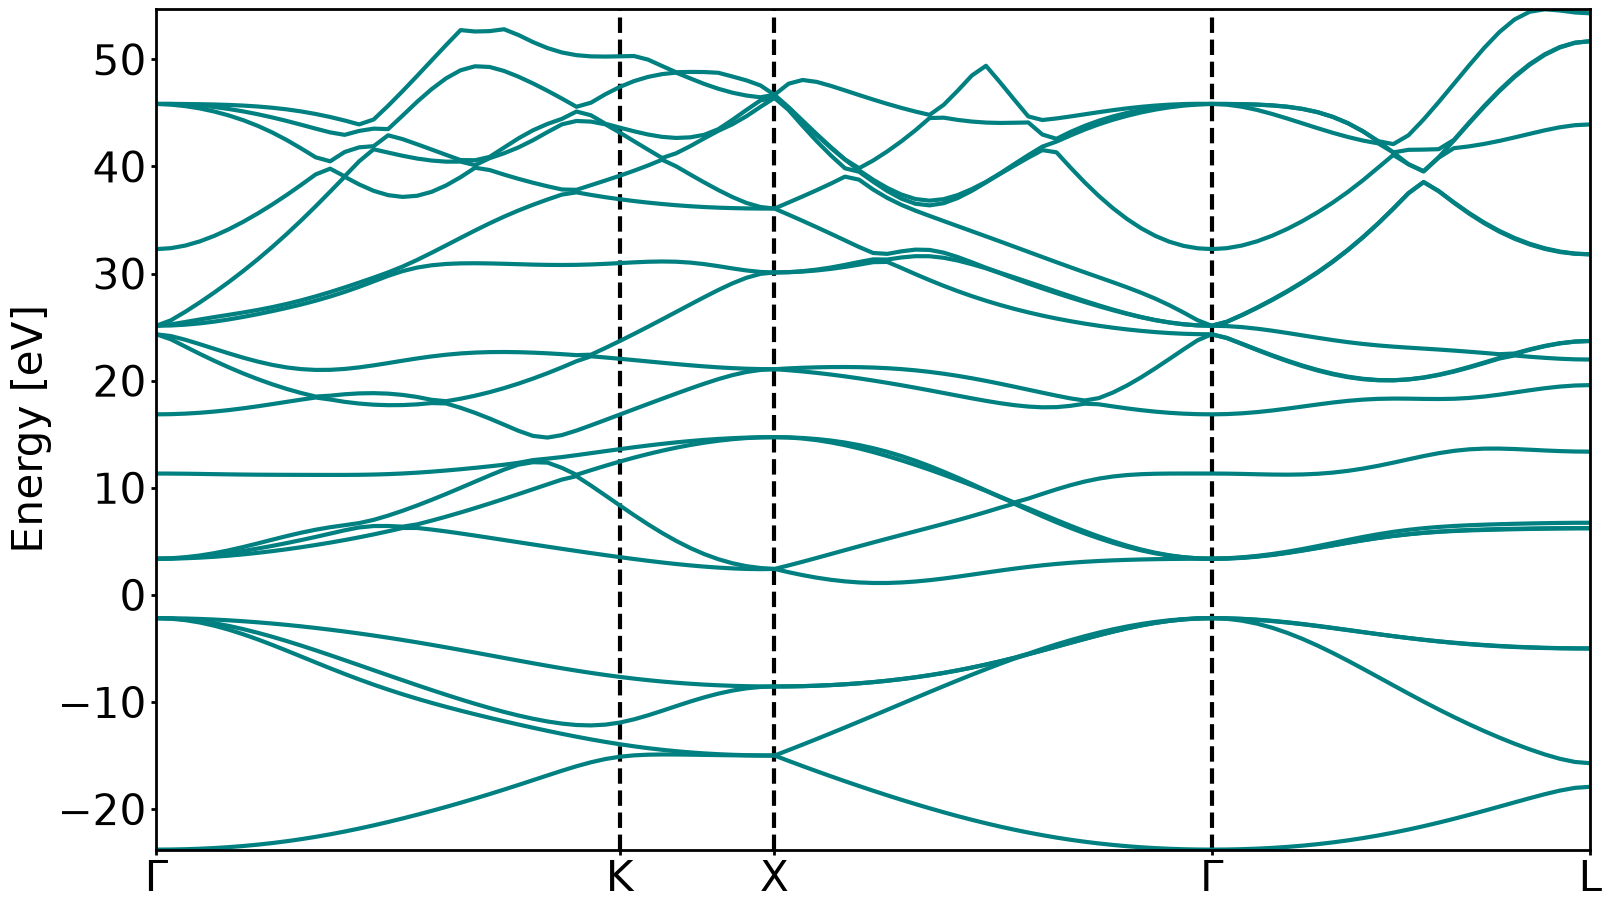
</figure>

Repeating the same for the the phonon dispersion (and changing the output unit) yields this:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_dispersion -disp eph_ph_disp.json -u icm
cp PLOT.png phonon_dispersion.png

<figure>
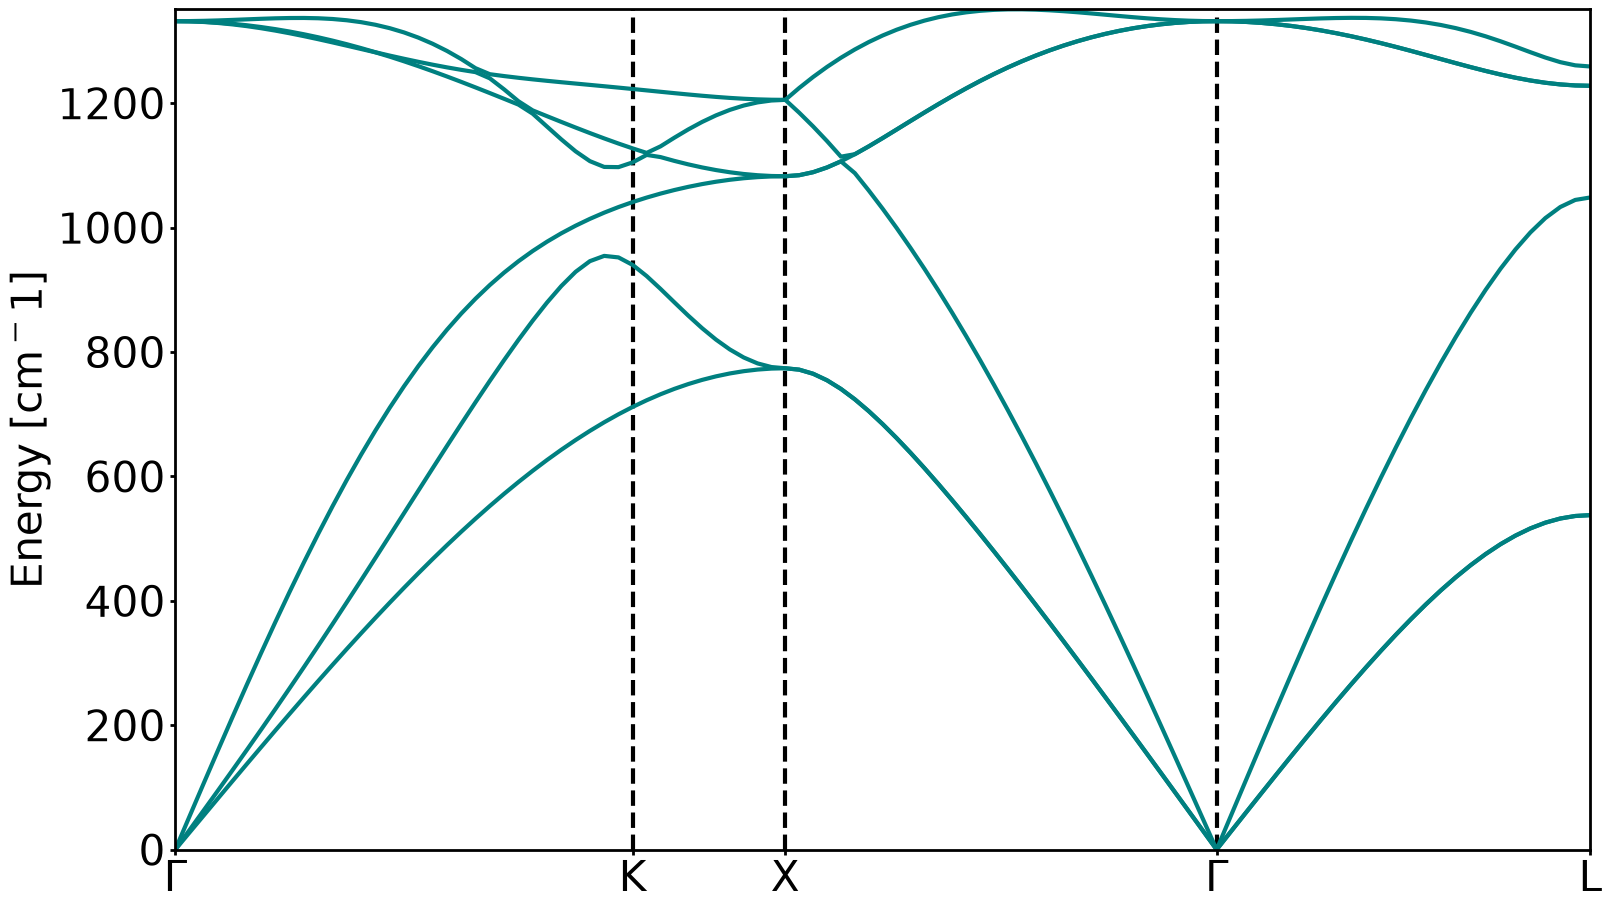
</figure>

We see that both dispersions look fine, telling us that the Wannier-Fourier interpolation is working correctly and that we are ready to proceed to the calculation of the electron self-energy.

<a id="4.2"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">4.2. Zero point renormalization</span>

In this part, we will compute the zero point renormalization (ZPR) of the band edges, *i.e.*, the change in the electronic energies due to zero point vibrations at $T=0\,{\rm K}$. We will start with the Gamma point.  

To do so, we modify the <code><span style="color:green">eph</span></code> element in the input file as follows and save the modified input in the file `input_ZPR_Gamma.xml`.

```xml
<eph wfrange="1 18">
  <ephmat do="fromscratch"/>
  <target ngridp="1 1 1" vploff="0.0 0.0 0.0"/>
  <el_self_energy
    do="fromscratch"
    ngridbz="15 15 15"
    vbzoff="0.12 0.23 0.34"
    eqpsolver="0"
    >
    <output_settings directory="Gamma" format="json"/>
  </el_self_energy>
</eph>
```

In [ ]:
# Read input file into ExctingInput object:
exciting_input = ExcitingInputXML.from_xml(eph_dir / 'input_check.xml')

del(exciting_input.eph.el_interpolation)
del(exciting_input.eph.ph_interpolation)
# save path for later
target_path = exciting_input.eph.target

exciting_input.eph.ephmat = {'do': 'fromscratch'}
exciting_input.eph.target = {'ngridp': [1, 1, 1], 'vploff': [0.0, 0.0, 0.0]}
exciting_input.eph.el_self_energy = {
  'do': 'fromscratch',
  'ngridbz': [15, 15, 15],
  'vbzoff': [0.12, 0.23, 0.34],
  'eqpsolver': 0,
  'output_settings': {
    'directory': 'Gamma',
    'format': 'json'
  }
}

exciting_input.write(eph_dir / 'input_ZPR_Gamma.xml')

The new input has the following meaning:

The element <code><span style="color:green">ephmat</span></code> triggers the calculation of the electron-phonon matrix elements $g_{mn,\nu}({\bf k},{\bf q})$.


We changed the <code><span style="color:green">target</span></code> to a regular grid. In this case, it's simply a $1 \times 1 \times 1$ grid without offset to represent only the Gamma point.


The element <code><span style="color:green">el_self_energy</span></code> controls the calculation of the electron self-energy:  
<code><span style="color:mediumblue">ngridbz</span></code> specifies the dense ${\bf q}$-grid used for the Brillouin zone integral.  
<code><span style="color:mediumblue">vbzoff</span></code> specifies the offset of the integration grid. We recommend to shift the grid to break symmetry in order to sample fewer redundant points and also to avoid the singularity at ${\bf q}=0$ in polar materials (not present in this example).  
<code><span style="color:mediumblue">eqpsolver</span></code> specfies how we solve the quasi-particle equation $\epsilon_{n{\bf k}}^{\rm QP} = \epsilon_{n{\bf k}}^0 + \Sigma^{\rm eph}_{n{\bf k}}(\epsilon_{n{\bf k}}^{\rm QP})$ . In principle, this can be a difficult challenge. The QP equation might have multiple solutions. Further, the QP energies are complex with the imaginary part being related to the QP life time. In turn, this requires to evaluate the self-energy $\Sigma_{n{\bf k}}(z)$ at complex arguments $z$ and thus some kind of analytic continuation. The code offers four different approximations to solve this problem:  

0\. $\epsilon_{n{\bf k}}^{\rm QP} = \epsilon_{n{\bf k}}^0 + \Sigma_{n{\bf k}}(\epsilon_{n{\bf k}}^0)$  
1\. $\epsilon_{n{\bf k}}^{\rm QP} = \epsilon_{n{\bf k}}^0 + Z_{n{\bf k}}\, \Sigma_{n{\bf k}}(\epsilon_{n{\bf k}}^0)$ with the real QP factor $Z_{n{\bf k}} = \frac{1}{1 - \Re\Sigma'_{n{\bf k}}(\epsilon_{n{\bf k}}0)}$  
2\. $\epsilon_{n{\bf k}}^{\rm QP} = \epsilon_{n{\bf k}}^0 + Z_{n{\bf k}}\, \Sigma_{n{\bf k}}(\epsilon_{n{\bf k}}^0)$ with the complex QP factor $Z_{n{\bf k}} = \frac{1}{1 - \Sigma'_{n{\bf k}}(\epsilon_{n{\bf k}}0)}$  
3\. $\epsilon_{n{\bf k}}^{\rm QP} = \epsilon_{n{\bf k}}^0 + \Sigma_{n{\bf k}}(\Re\epsilon_{n{\bf k}}^{\rm QP})$  

Option 0 is the simplest one, also called on-the-mass-shell approximation. Options 1 and 2 are based on expanding the self-energy on the real frequency axis around the bare energies up to the 1st order in the real part (1) or both real and imaginary part (2). Option 3 iteratively finds a fixed point for the real part of the QP energy along the real frequency axis.

Lastly, we specify the output format of the human readable files (JSON) and the name of the directory to which these files will be written (**Gamma**) using the subelement <code><span style="color:green">output_settings</span></code>.

Now, let's run the calculation:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

# run exciting
python3 -m excitingscripts.setup.excitingroot -i input_ZPR_Gamma.xml -o input_ZPR_Gamma.xml
time python3 -m excitingscripts.execute.single -f input_ZPR_Gamma.xml

Let's have a look into the output directory that we have specified:

In [ ]:
%%bash
cd run_temperature_dependent_band_gap/eph

ls Gamma

The output in which we are interested at the moment is the file `EVALQP_T0000.dat`. Let's have a look:

In [ ]:
%%bash
cd run_temperature_dependent_band_gap/eph

head Gamma/EVALQP_T0000.dat -n 7

For each ${\bf k}$-point and state $n$, this files contains the Kohn-Sham energies $\epsilon_{n{\bf k}}^{\rm KS}$, the real and imaginary part of the QP energies $\epsilon_{n{\bf k}}^{\rm QP}$ as well as the Fan-Migdal and Debye-Waller self-energies and their respective contribution from the high and low energy states (not discussed within this tutorial). The column `DE_EPH[Ha]` shows the renormalization of each band and the last two columns show the QP factor $Z_{n{\bf k}}$.  
The KS and QP energies are given relative to the Fermi level. Therefore, band 4 corresponds to the highest occupied band and band 5 to the lowest unoccupied one. In order to find the ZPR at Gamma, you can either extract and convert the values yourself or use the provided script `eph_gap_renormalization` and provide the name of the directory in which we want to search for the result using the argument `-d`:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_gap_renormalization -d Gamma 

We find a renormalization of about 150 meV for the valenece band and -220 meV for the conduction band, resulting in a total renormalization of the direct band gap of around -370 meV.

In order to repeat the calculation of the conduction band minimum (CBM), which is located at the point `[0.38 0.0 0.38]` in lattice coordinates, modify the input file as following:
```xml
<eph wfrange="1 18">
  <target ngridp="1 1 1" vploff="0.38 0.0 0.38"/>
  <el_self_energy
    do="fromscratch"
    ngridbz="15 15 15"
    vbzoff="0.12 0.23 0.34"
    eqpsolver="0"
    >
    <output_settings directory="CBM" format="json"/>
  </el_self_energy>
</eph>
```
Note, that we have removed the element <code><span style="color:green">ephmat</span></code>, because we have already computed the matrix elements in the step before.

We save the modified input in the file `input_ZPR_CBM.xml`:

In [ ]:
# Read input file into ExctingInput object:
exciting_input = ExcitingInputXML.from_xml(eph_dir / 'input_ZPR_Gamma.xml')

del(exciting_input.eph.ephmat)

exciting_input.eph.target = {'ngridp': [1, 1, 1], 'vploff': [0.38, 0.0, 0.38]}
exciting_input.eph.el_self_energy.output_settings.directory = 'CBM'

exciting_input.write(eph_dir / 'input_ZPR_CBM.xml')

Rerun the code:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

# run exciting
python3 -m excitingscripts.setup.excitingroot -i input_ZPR_CBM.xml -o input_ZPR_CBM.xml
time python3 -m excitingscripts.execute.single --input-file input_ZPR_CBM.xml

We can use the script `eph_gap_renormalization` again to extract the ZPR of the indirect gap. This time, we provide both directories via `-d` and additionally specify the vectors for the valence and conduction band via `-vvb` and `-vcb`, respectively.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_gap_renormalization -d Gamma CBM -vvb 0 0 0 -vcb 0.38 0 0.38

We find a shift of -92 meV for the CBM corresponding leading to a total closing of the indirect band gap of -243 meV.

<a id="4.3"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">4.3. Temperature dependent band gap</span>

In this part, we will compute the temperature dependence of the direct band gap and Gamma. Therefore, we simply need to repeat the previous task for several temperatures. Therefore, the only new input attribute that we need is <code><span style="color:mediumblue">tempset</span></code> within <code><span style="color:green">el_self_energy</span></code>. This attribute takes three numbers specifying the lower and upper bound of the requested temperature range and an increment. Here, we will compute the renormalization for temperatures ranging from 0 K to 800 K in 50 K steps.

Change the input file to read:
```xml
<eph wfrange="1 18">
  <target ngridp="1 1 1" vploff="0.0 0.0 0.0"/>
  <el_self_energy
    do="fromscratch"
    ngridbz="15 15 15"
    vbzoff="0.12 0.23 0.34"
    eqpsolver="0"
    tempset="0 800 50"
    >
    <output_settings directory="Gamma_temperature"/>
  </el_self_energy>
</eph>
```

Save the modified input in the file `input_Gamma_temperature.xml`.

In [ ]:
# Read input file into ExctingInput object:
exciting_input = ExcitingInputXML.from_xml(eph_dir / 'input_ZPR_CBM.xml')

exciting_input.eph.target = {'ngridp': [1, 1, 1], 'vploff': [0.0, 0.0, 0.0]}
exciting_input.eph.el_self_energy.tempset = [0, 800, 50]
exciting_input.eph.el_self_energy.output_settings.directory = 'Gamma_temperature'

exciting_input.write(eph_dir / 'input_Gamma_temperature.xml')

And run the code:

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

# run exciting
python3 -m excitingscripts.setup.excitingroot -i input_Gamma_temperature.xml -o input_Gamma_temperature.xml
time python3 -m excitingscripts.execute.single -f input_Gamma_temperature.xml

We now find a separate output file for each temperature in the directory:

In [ ]:
%%bash
cd run_temperature_dependent_band_gap/eph

ls Gamma_temperature

Again, we use the script `eph_gap_renormalization` to extract the results. We additionally set the argument `-p` to plot the results.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_gap_renormalization -d Gamma_temperature -p
cp PLOT.png direct_gap_vs_temperature.png

This produces the following plot:

<figure>
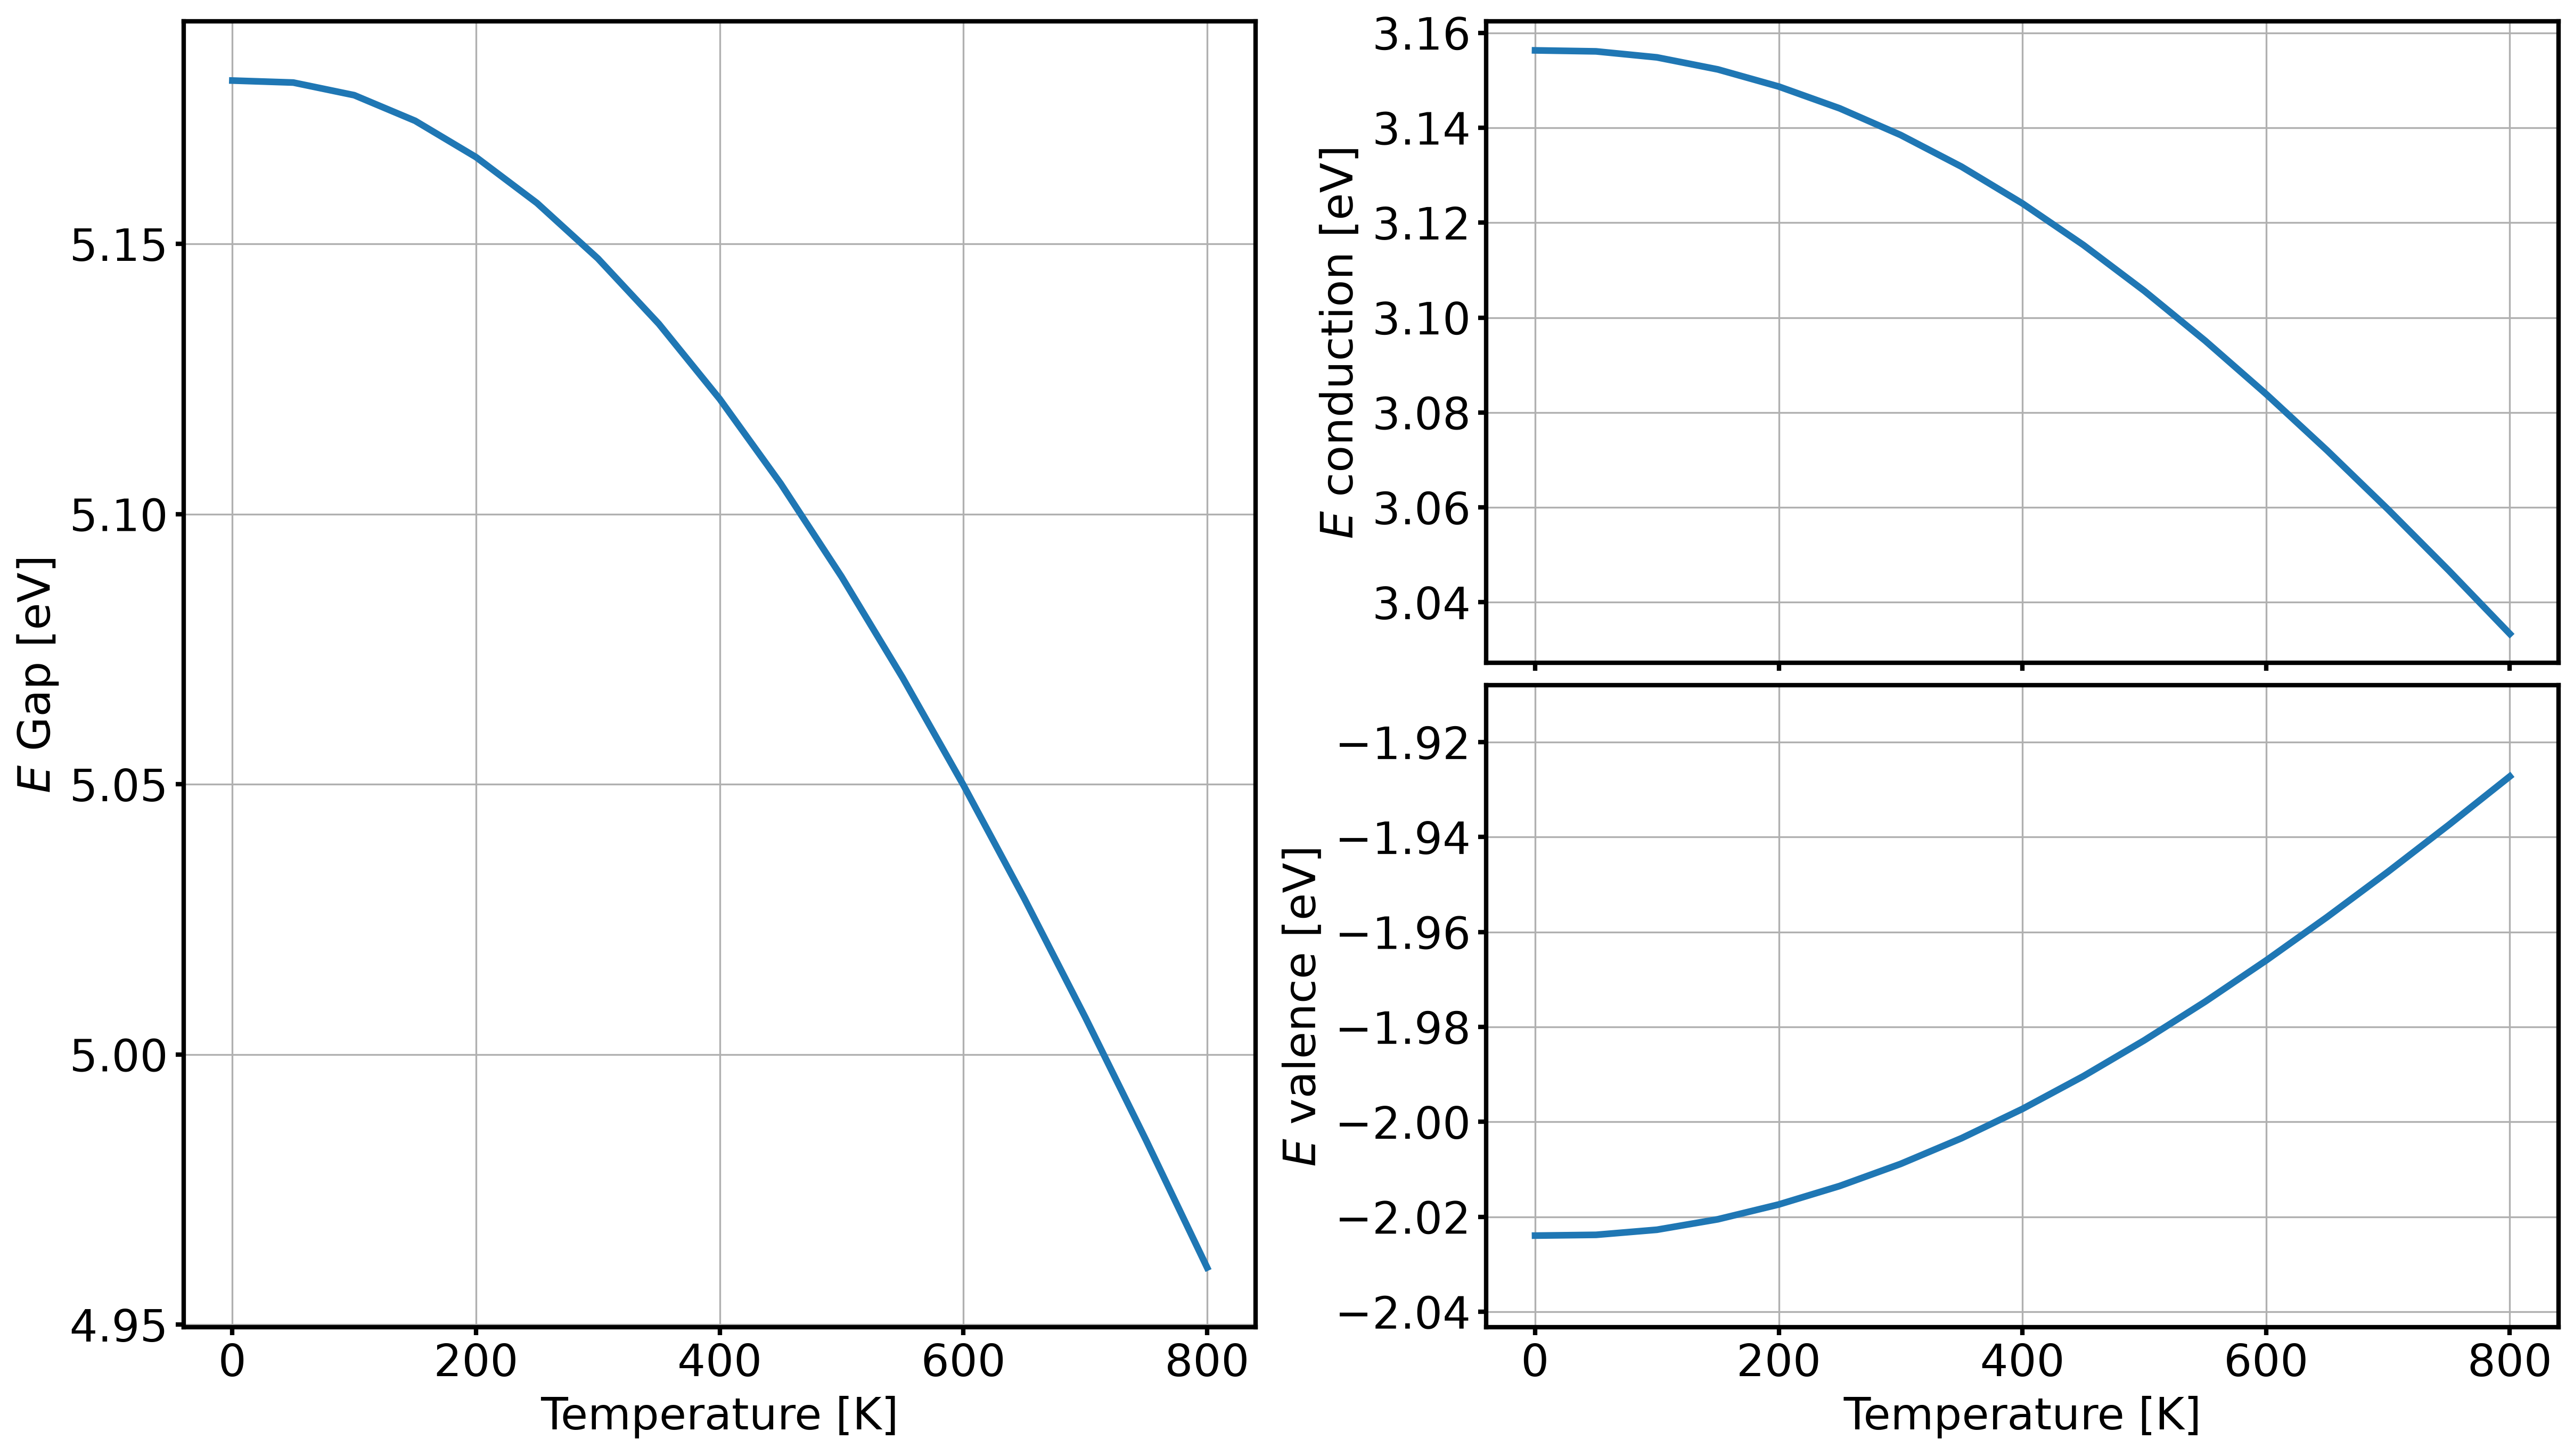
</figure>

On the left, we see the typical drop of the band gap with increasing temperature found for most semiconductors. On the right, we see the change in the valence (bottom) and conduction (top) band energy.  
Note, that both panels on the right span the same energy range on the vertical axis to make the different changes visually directly comparable.

Also try out the `--renorm` argument to plot the renormalization, *i.e.*, only the change in energy instead of the absolute energies.

<a id="4.4"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">4.4. Renormalized band structure and spectral function</span>

Finally, we are going to compute the full band structure at room temperature. Therefore, we set the <code><span style="color:green">target</span></code> back to the Brillouin zone path and set <code><span style="color:mediumblue">tempset</span></code> to `"300 300 0"` which will only contain the single temperature 300 Kelvin. The output will redirected to the directory **path_300K**.

```xml
<eph wfrange="1 18">
  <target>      
    <plot1d>
      <path steps='100'>
        <point coord='1.0     0.0     0.0' label='Gamma'/>
        <point coord='0.625   0.375   0.0' label='K'/>
        <point coord='0.5     0.5     0.0' label='X'/>
        <point coord='0.0     0.0     0.0' label='Gamma'/>
        <point coord='0.5     0.0     0.0' label='L'/>
      </path>
    </plot1d>
  </target>  
  <el_self_energy
    do="fromscratch"
    ngridbz="15 15 15"
    vbzoff="0.12 0.23 0.34"
    eqpsolver="0"
    tempset="300 300 0"
    >
    <output_settings directory="path_300K" format="json"/>
  </el_self_energy>
</eph>
```

Let's save the input to the file `input_QP_disp.xml`...

In [ ]:
# Read input file into ExctingInput object:
exciting_input = ExcitingInputXML.from_xml(eph_dir / 'input_ZPR_Gamma.xml')

exciting_input.eph.target = target_path
exciting_input.eph.el_self_energy.tempset = [300, 300, 0]
exciting_input.eph.el_self_energy.output_settings.directory = 'path_300K'

exciting_input.write(eph_dir / 'input_QP_disp.xml')

... and run the code.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

# run exciting
python3 -m excitingscripts.setup.excitingroot -i input_QP_disp.xml -o input_QP_disp.xml
time python3 -m excitingscripts.execute.single -f input_QP_disp.xml

We can again use the script `eph_dispersion` to compare the bare DFT band structure with renormalized band structure at room temperature. To this end, we use both the `-disp` argument to specify the bare band structure and the `-qp` argument to specify the quasi-particle band structure. We also zoom in to the region around the band gap by specifying the energy range -5 eV to 5 eV using the argument `-e`.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_dispersion -disp eph_el_disp.json -qp path_300K/eph_el_qp_disp_T0300.json -e -5 5
cp PLOT.png QP_dispersion_300K.png

This generates the following plot showing the bare (solid teal) and renormalized (dashed red) band structure. The shaded red area shows the linewidth of the quasi-particles given by the imaginary part of the QP energies.

<figure>
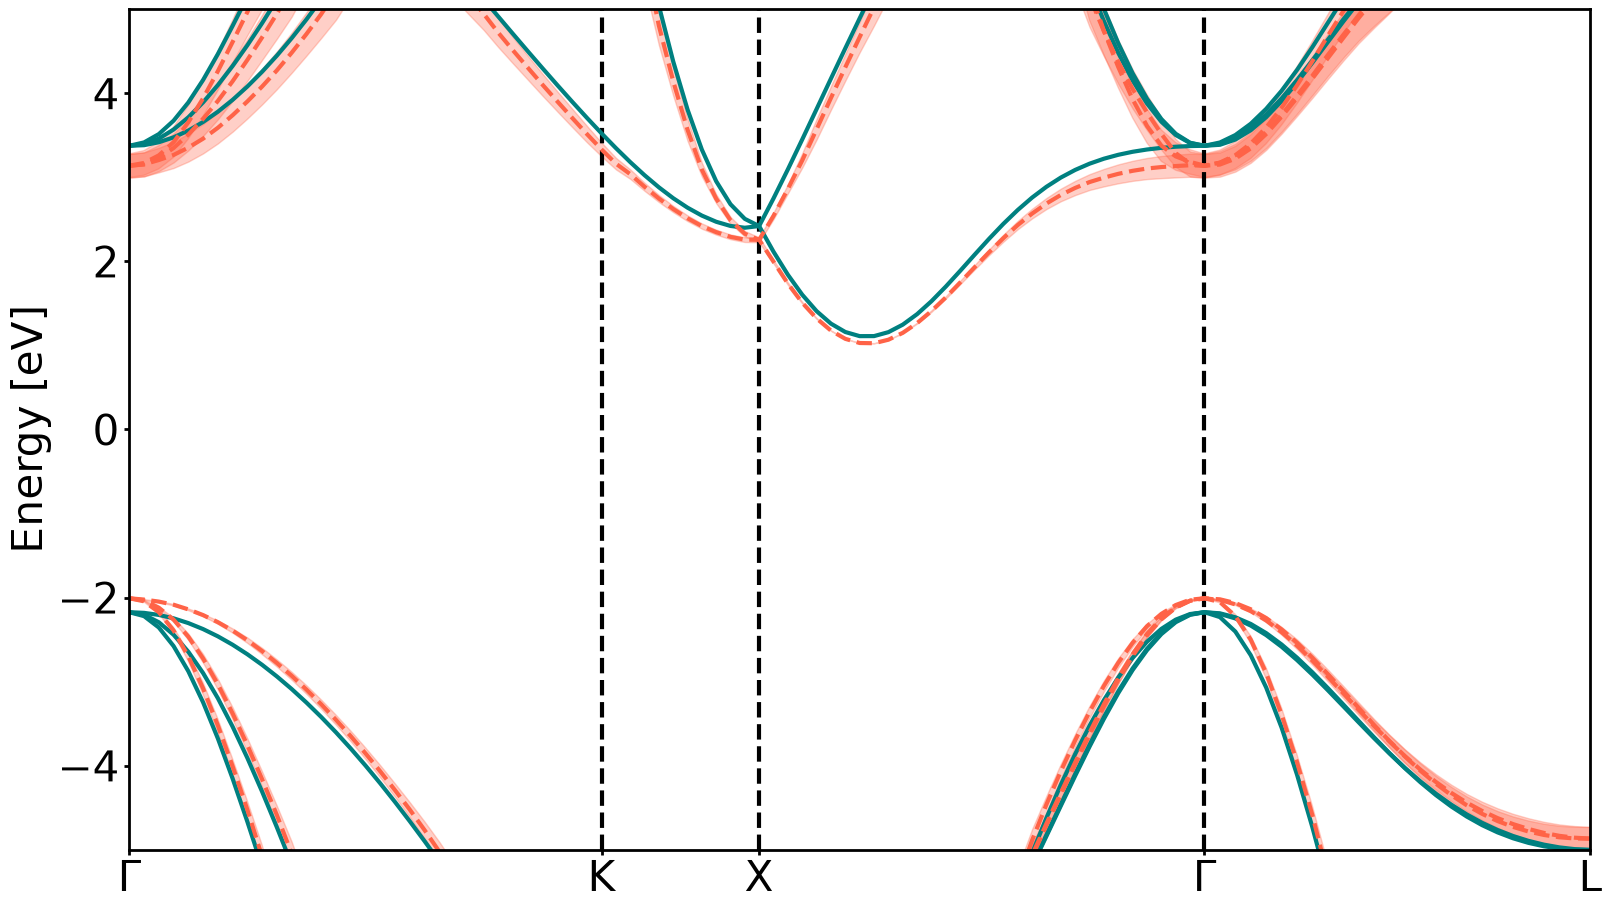
</figure>

We can also plot the spectral function

$$
A({\bf k},\omega;T) = -\frac{1}{\pi} \sum_n \frac{\Im \Sigma^{\rm eph}_{n{\bf k}}(\omega;T)}{\Big[\omega - \Big(\epsilon^0_{n{\bf k}} + \Re \Sigma^{\rm eph}_{n{\bf k}}(\omega;T)\Big) \Big]^2 + \Big[\Im \Sigma^{\rm eph}_{n{\bf k}}(\omega;T)\Big]^2} \tag{3}
$$

which has the meaning of a momentum resolved density of states and can be experimentally probed using *e.g.* angular resolved photoemission spectroscopy (ARPES). The spectral function shows excitation energies and particle lifetimes as peaks with a finite width and may also show additional features like satellites which cannot be explained within the single quasi-particle picture. This is the more complete description of the band structure of a material compared to the DFT band structure which is the limit of Eq. (3) in the case of a vanishing self-energy leading to a sum of Dirac delta peaks $\delta(\omega - \epsilon^0_{n{\bf k}})$ centered at the bare electron energies.  

The self-energy $\Sigma^{\rm eph}_{n{\bf k}}(\omega;T)$ and the corresponding spectral function is available in the human readable files `eph_else+sfun_P###_T####.json`. For each ${\bf k}$-point `P###` in the defined target and each temperature `T####` these files contain the frequency grid, the real and imaginary part of the self-energy and the spectral function for each band $n$. In the files with the prefix `eph_else+sfun` all bands share the same frequency grid. In the files with the prefix `eph_else+sfun_rsmpld` the self-energy and spectral function has been resampled using interpolation to a frequency grid that is densely sampled around the main features in the spectral function for better resolution in the interesting regions, thus each band comes with its own frequency grid.

We can plot the spectral function using the script `eph_dispersion` again. We can specify all files for the spectral function using the argument `-sfun`. We provide the files for all points along the path using the wildcard character `*`. We also want to plot the bare DFT band structure for comparison. We can specify the line color for the bare and QP band structure via the argument `-lc`. Since the latter is not specified in this example, we can provide any value for the second color.

In [ ]:
%%bash -l
cd run_temperature_dependent_band_gap/eph

python3 -m excitingscripts.plot.eph_dispersion -disp eph_el_disp.json -e -5 5 -sfun path_300K/eph_else+sfun_rsmpld_P*_T0300.json -lc black None
cp PLOT.png spectral_function+electron_dispersion.png

This produces the following plot:

<figure>
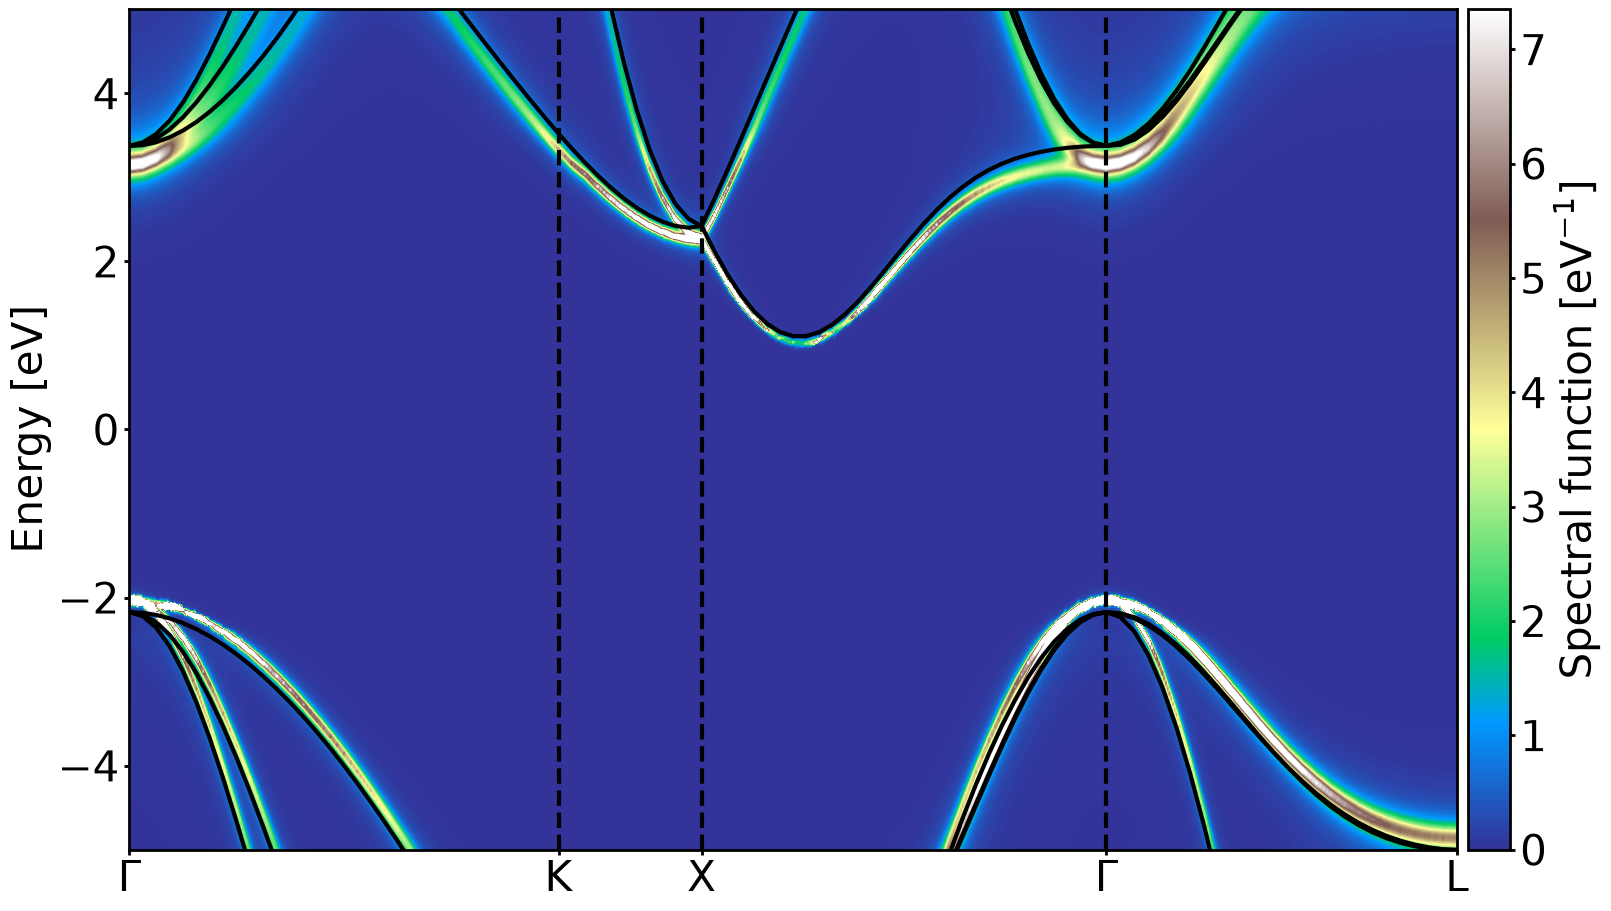
</figure>

**Congratulations!** You have now reached the end of the practical part of this tutorial. The following sections provide documentation and additional notes for the technically interested user.

<a id="5"></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">5. Documentation, Technical Notes and Practical Tips</span>

<a id="5.1"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">5.1 Output files</span>

| File | Format | Symbol | Comment |
|-----:|:----:|:-------|:--------|
| `EPH_Uk.OUT` | binary | $$U_{mn}({\bf k})$$ | Wannier transformation matrices on coarse ${\bf k}$-grid<br>automatically generated on first electron interpolation<br>read from file, if present |
| `EPH_HR.OUT` | binary | $$H_{mn}({\bf R}_e)$$ | real-space representation of Hamiltonian in Wannier gauge<br>automatically generated on first electron interpolation<br>read from file, if present |
| `EPH_DR.OUT` | binary | $$\Phi_{\kappa\alpha,\kappa'\alpha'}({\bf R}_p)$$ | real-space representation of dynamical matrix in atomic gauge (interatomic force constants, IFCs)<br>automatically generated on first phonon interpolation<br>read from file, if present |
| `EPH_GKQ.OUT` | binary | $$g_{mn,\kappa\alpha}({\bf k},{\bf q})$$ | eph matrix elements on coarse ${\bf k}$ and ${\bf q}$-grid in atomic Hamiltonian gauge<br>generated using element <code><span style="color:green">\<ephmat\></span></code> with attribute <code><span style="color:mediumblue">standard</span>="true"</code> |
| `EPH_GFMHILOKQ.OUT`<br>`EPH_GDWHILOKQ.OUT` | binary | $$g^{\rm FM, hilo}_{n,\nu}({\bf k},{\bf q})$$<br>$$g^{\rm DW, hilo}_{n,\nu}({\bf k},{\bf q})$$ | matrix elements for high and low energy contribution to FM and DW self-energy on coarse ${\bf k}$ and ${\bf q}$-grid<br>(used to compute the contribution to the sum over states $\sum_m$ that does not come from the bands described by MLWFs)<br>generated using element <code><span style="color:green">\<ephmat\></span></code> with attribute <code><span style="color:mediumblue">hilo</span>="true"</code> |
| `EPH_GRR.OUT` | binary | $$g_{mn,\kappa\alpha}({\bf R}_e,{\bf R}_p)$$ | real-space representation of eph matrix elements in atomic Wannier gauge<br>automatically generated on first eph matrix interpolation<br>read from file, if present |
| `EPH_ELSE.OUT` | binary | $$\Sigma_{n{\bf k}}(\omega;T)$$ | electron self-energy for all target ${\bf k}$-points and temperatures<br>can be reused for same target, temperatures and frequencies via attribute `do="fromfile"`<br>has to be recomputed, if any of those parameters has changed |
| `eph_el_loc.dat` | text | $$\|{\bf H}({\bf R}_e)\|$$ | spatial localization of real-space Hamiltonian |
| `eph_ph_loc.dat` | text | $$\|\boldsymbol{\Phi}({\bf R}_p)\|$$ | spatial localization of IFCs |
| `eph_ephmat_loc_el.dat`<br>`eph_ephmat_loc_ph.dat`<br>`eph_ephmat_loc_el_q0.dat` | text | $$\|{\bf g}({\bf R}_e,{\bf R}_p=0)\|$$<br>$$\|{\bf g}({\bf R}_e=0,{\bf R}_p)\|$$<br>$$\|{\bf g}({\bf R}_e,{\bf q}=0)\|$$ | spatial localization of real-space eph matrix |
| `eph_el_disp.xxx`<br>`eph_el_energies.xxx` | text<br>JSON | $$\epsilon^0_{n{\bf k}}$$ | interpolated electron energies on target ${\bf k}$-points<br>generated using <code><span style="color:green">\<el_interpolation\></span></code> |
| `eph_ph_disp.xxx`<br>`eph_ph_energies.xxx` | text<br>JSON | $$\omega_{\nu{\bf q}}$$ | interpolated phonon energies on target ${\bf q}$-points<br>generated using <code><span style="color:green">\<ph_interpolation\></span></code> |
| `eph_ephmat.xxx` | text<br>JSON | $$g_{mn,\nu}({\bf k},{\bf q})$$ | interpolated eph matrix on target ${\bf k}/{\bf q}$-points with the other wavevector fixed<br>generated using <code><span style="color:green">\<eph_interpolation\></span></code> |
| `eph_el_qp_disp_T####.xxx`<br>`eph_el_qp_energies_T####.xxx` | text<br>JSON | $$\epsilon^{\rm QP}_{n{\bf k}}$$ | QP energies for given temperature on target ${\bf k}$-points<br>generated using <code><span style="color:green">\<el_self_energy\></span></code> |
| `eph_else+sfun_P###_T####.xxx` | text<br>JSON | $$\Sigma^{\rm eph}_{n{\bf k}}(\omega;T)$$<br>$$A_{n{\bf k}}(\omega;T)$$ | electron self-energy and spectral function of each band at given ${\bf k}$-point from target and temperature<br>generated using <code><span style="color:green">\<el_self_energy\></span></code> |
| `EVALQP_T####.dat` | text | - | KS and QP energies and various self-energy contributions for given temperature on target ${\bf k}$-points<br>generated using <code><span style="color:green">\<el_self_energy\></span></code> |
| `EVALQP_T####.OUT` | binary | - | binary file that is compliant with format of `EVALQP.OUT` from $GW$ calculation<br>Might be used in other parts of the code (*e.g.* BSE) instead of $GW$ output. **Experimental!**<br>Generated using <code><span style="color:green">\<el_self_energy\></span></code> and only, if <code><span style="color:green">\<target\></span></code> is not specified. Then, the original coarse ${\bf k}$-grid will be the target. |


<a id="5.2"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">5.2 Convergence</span>

As all types of calculations, also electron-phonon calculations have to be converged to a desired precission with respect to several quantities. Here are a few considerations.

##### Coarse ${\bf k}$ and ${\bf q}$-grids

They mainly determine the quality of the Wannier and Fourier interpolation of electron and phonon energies and the eph matrix elements. The electrons are typically not difficult to converge with respect to the ${\bf k}$-grid. Phonon calculations are more expensive. You can start with a coarse ${\bf q}$-grid and plot the interpolated phonon dispersion. Now incrementally refine the grid up to a point at which the phonon dispersion is converged. Choose finer grids that contain the coarser grids as subgrids. That way, you only need to compute the missing ${\bf q}$ points.  
The quality of the Wannier-Fourier interpolation can also be assessed by consulting the files `eph_el_loc.dat`, `eph_ph_loc.dat` and `eph_ephmat_loc_el.dat` and `eph_ephmat_loc_ph.dat`. They contain the spatial localization of the respective real-space representations. If all objects are sufficiently decayed for the largest $|{\bf R}|$ within the Born-von-Kármán super cell corresponding to the respective ${\bf k}$ and ${\bf q}$-grid, then the interpolation is accurate.

In the case of Diamond, we find that both ${\bf k}$ and ${\bf q}$-grid are sufficiently converged at $8 \times 8 \times 8$ and higher.

##### Fine ${\bf k}$ and ${\bf q}$-grids for BZ integrals

The Brillouin zone integral over ${\bf q}$ in the self-energy expressions Eqs. (1) and (2) is more difficult to converge. In the default settings, we do not compute the expression given in Eq. (1) with the infinitesimal smearing parameter $\eta$. If we would do so, a converged calculation would correspond to a very small value of $\eta$ (*e.g.* 1 meV). However, the smaller $\eta$ the finer the ${\bf q}$-grid has to be. For such a small value of $\eta$, an integration grid in the order of $100 \times 100 \times 100$ would be required.  
Instead, we compute the imaginary part of Eq. (1) in the limit $\eta \rightarrow 0$ which reads
$$
\Im \Sigma^{\rm FM}_{n{\bf k}}(\omega;T) = -\pi \sum_{\nu} \int\limits_{\rm BZ} \frac{{\rm d}{\bf q}}{V_{\rm BZ}} \sum_m |g_{mn,\nu}({\bf k},{\bf q})|^2 \Big[ \Big(1-f_{m{\bf k}+{\bf q}}(T) + n_{\nu{\bf q}}(T)\Big) \delta(\omega - \epsilon^0_{m{\bf k}+{\bf q}} - \omega_{\nu{\bf q}}) + \Big(f_{m{\bf k}+{\bf q}}(T) + n_{\nu{\bf q}}(T)\Big) \delta(\omega - \epsilon^0_{m{\bf k}+{\bf q}} + \omega_{\nu{\bf q}}) \Big] \;.
$$
Integrals with Dirac deltas like that are efficiently evaluated using **tetrahedron integration**. This method gives the correct limit for an infinitesimal $\eta$ and typically converges much faster than the direct implementation of Eq. (1) with a sufficiently small value for $\eta$. Then, the real part of the self-energy can be obtained from the imaginary part using the **Kramers-Kronig relations**. This is the default setting in **`exciting`**.  

In the case of Diamond, an integration grid of around $40 \times 40 \times 40$ can be considered as converged (with tetrahedron integration).

##### Frequency grid

The frequency grid plays two roles. The more important one is a drawback of the tetrahedron approach described before. An accurate reconstruction of the real part of the self-energy from the imaginary part, requires to know the imaginary part along the full frequency axis in a sufficiently high resolution. Fortunately, the imaginary part is zero outside the energy range spanned by the electron energies $\epsilon^0_{m{\bf k}}$ considered in the sum $\sum_m$ thanks to the Dirac deltas.  
The second role is in the solution of quasi-particle equation. Here, we use interpolation on the real frequency axis and compute numerical derivatives of the self-energy. Both of which are more accurate with a dense frequency sampling.  
The number of frequency points can be set with the attribute <code><span style="color:mediumblue">nfreqperband</span></code> within <code><span style="color:green">\<el_self_energy\></span></code>. The total number of frequencies is that number times the number of Wannier bands. The default value is 20 frequency points per band.

##### Number of states

It is known, that both the FM and DW self-energy are very difficult to converge with respect to the number of bands considered in the sum over states $\sum_m$. However, there is a lot of cancellation happening in the sum of both contributions such that the total self-energy converges more quickly. Further, bands that are closer to energy range of interest are more important than states that are further away in energy. Therefore, internally, we split the sum over states into active bands (the ones described by Wannier functions) and inactive bands (all other bands). The active bands lead to the fine features in the frequency dependence of the self-energy. The inactive bands lead more to a overall shift of the real part of the self-energy. For the inactive bands, the BZ integral is evalutated on the coarse original ${\bf q}$-grid without interpolation. This is typically a good approximation.  

For practical calculations, we recommend doing the following. Let's assume, you are interested in the renormalization for the uppermost valence bands and a few low energy conduction bands. Wannierize the bands of interest and also include a generous number of additional bands beyond the bands of interest. Then, in the self-energy calculation, you can start with a smaller set of Wannier bands (*e.g.* only the bands of interest) specified using <code><span style="color:mediumblue">wfrange</span></code> and successively include more bands in the calculation and check the effect on the renormalized energies. The imaginary part of the self-energy does not depend at all on bands that are far away in energy from the bands of interest. The real part, however, does. The <code><span style="color:mediumblue">standard</span></code> matrix elements in the files `EPH_GKQ.OUT` and `EPH_GRR.OUT` do not need to be recomputed after changing <code><span style="color:mediumblue">wfrange</span></code>. The <code><span style="color:mediumblue">hilo</span></code> matrix elements, however, do have to be upated after each change of <code><span style="color:mediumblue">wfrange</span></code>.

<a id="5.3"></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">5.3 Parallelization</span>

Here, we will only discuss MPI parallelization.  

The calculation of the **eph matrix elements** using <code><span style="color:green">\<ephmat\></span></code> is parallelized over reduced ${\bf q}$-points and the full set of ${\bf k}$-points (both from the respective coarse grids).  
    In the example in this tutorial, we have <code><span style="color:mediumblue">ngridk</span>="4 4 4"</code> for the electrons and <code><span style="color:mediumblue">ngridq</span>="2 2 2"</code> for the phonons, which gives 64 points on the full ${\bf k}$-grid and 3 reduced ${\bf q}$-points which means that this task can be parallelized up to at most 3 times 64 = 192 processes.

The calculation of the **electron self-energy** using <code><span style="color:green">\<el_self_energy\></span></code> is parallelized over Wannier bands and phonon modes.  
In the example in this tutorial, we include 18 Wannier bands (<code><span style="color:mediumblue">wfrange</span>="1 18"</code>) and have 6 phonon modes which means that this task can be parallelized up to at most 18 times 6 = 108 processes.

<hr style="border:2px solid #DDD"> </hr>